<a href="https://colab.research.google.com/github/auliafakhirah/Fundamen-Sains-Data/blob/main/Tugas_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TUGAS DIMENSIONALITY REDUCTION
PCA dan t-SNE pada Dataset Wine **bold text**

Anggota :
 1. Aulia Fakhirah Hendraini
 2. Maulidya Iftitah


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os


os.makedirs('images', exist_ok=True)

print("Library berhasil diimport!")

Library berhasil diimport!


In [ ]:
# Load Dataset Wine
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print("="*50)
print("INFORMASI DATASET")
print("="*50)
print(f"Jumlah sampel: {X.shape[0]}")
print(f"Jumlah fitur: {X.shape[1]}")
print(f"Nama fitur: {feature_names}")
print(f"Jumlah kelas: {len(target_names)}")
print(f"Nama kelas: {target_names}")


df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
print("\n5 Data Pertama:")
print(df.head())

print("\nStatistik Deskriptif:")
print(df.describe())


print(f"\nMissing values: {df.isnull().sum().sum()}")

INFORMASI DATASET
Jumlah sampel: 178
Jumlah fitur: 13
Nama fitur: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Jumlah kelas: 3
Nama kelas: ['class_0' 'class_1' 'class_2']

5 Data Pertama:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76             

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data berhasil distandarisasi!")
print(f"Mean setelah standarisasi: {X_scaled.mean(axis=0).round(2)}")
print(f"Std setelah standarisasi: {X_scaled.std(axis=0).round(2)}")

Data berhasil distandarisasi!
Mean setelah standarisasi: [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]
Std setelah standarisasi: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


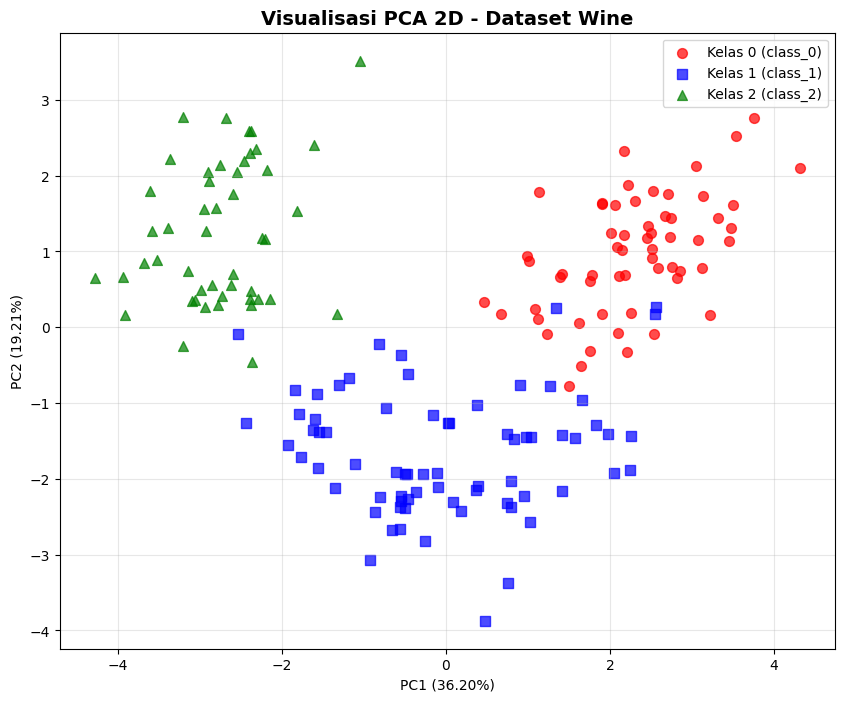


HASIL PCA
Total variance explained (2 komponen): 55.41%
PC1: 36.20% variance
PC2: 19.21% variance

Komponen PCA (feature weights):
alcohol             : PC1=0.144, PC2=0.484
malic_acid          : PC1=-0.245, PC2=0.225
ash                 : PC1=-0.002, PC2=0.316
alcalinity_of_ash   : PC1=-0.239, PC2=-0.011
magnesium           : PC1=0.142, PC2=0.300
total_phenols       : PC1=0.395, PC2=0.065
flavanoids          : PC1=0.423, PC2=-0.003
nonflavanoid_phenols: PC1=-0.299, PC2=0.029
proanthocyanins     : PC1=0.313, PC2=0.039
color_intensity     : PC1=-0.089, PC2=0.530
hue                 : PC1=0.297, PC2=-0.279
od280/od315_of_diluted_wines: PC1=0.376, PC2=-0.164
proline             : PC1=0.287, PC2=0.365


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']

for i, target_name in enumerate(target_names):
    plt.scatter(X_pca[y==i, 0], X_pca[y==i, 1],
                c=colors[i], label=f'Kelas {i} ({target_name})',
                alpha=0.7, s=50, marker=markers[i])

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('Visualisasi PCA 2D - Dataset Wine', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.savefig('images/pca_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("HASIL PCA")
print("="*50)
print(f"Total variance explained (2 komponen): {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.2f}% variance")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.2f}% variance")
print(f"\nKomponen PCA (feature weights):")
for i, feature in enumerate(feature_names):
    print(f"{feature:20s}: PC1={pca.components_[0][i]:.3f}, PC2={pca.components_[1][i]:.3f}")

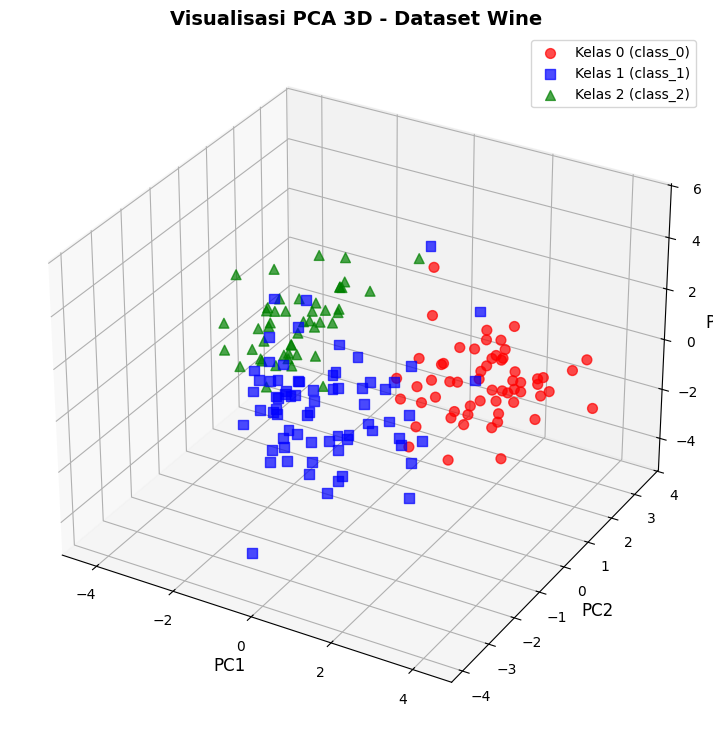


Total variance explained (3 komponen): 66.53%


In [ ]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for i, target_name in enumerate(target_names):
    ax.scatter(X_pca_3d[y==i, 0], X_pca_3d[y==i, 1], X_pca_3d[y==i, 2],
               c=colors[i], label=f'Kelas {i} ({target_name})',
               alpha=0.7, s=50, marker=markers[i])

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_zlabel('PC3', fontsize=12)
ax.set_title('Visualisasi PCA 3D - Dataset Wine', fontsize=14, fontweight='bold')
ax.legend()

plt.savefig('images/pca_3d.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTotal variance explained (3 komponen): {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

Menjalankan t-SNE... (mungkin butuh beberapa detik)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


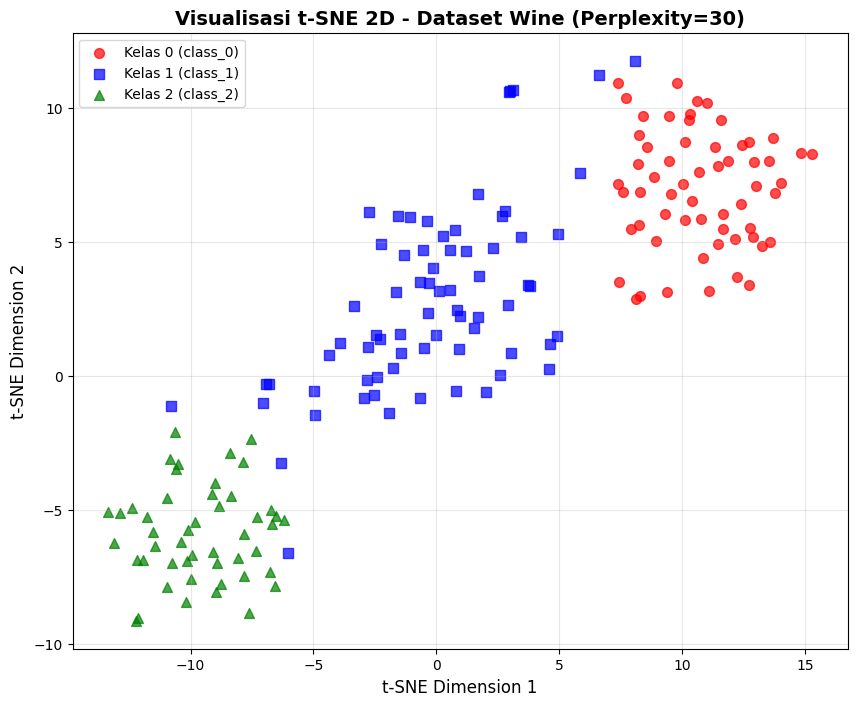


t-SNE selesai dijalankan!


In [ ]:
print("Menjalankan t-SNE... (mungkin butuh beberapa detik)")
tsne = TSNE(n_components=2, random_state=42, perplexity=30,
            learning_rate=200, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))

for i, target_name in enumerate(target_names):
    plt.scatter(X_tsne[y==i, 0], X_tsne[y==i, 1],
                c=colors[i], label=f'Kelas {i} ({target_name})',
                alpha=0.7, s=50, marker=markers[i])

plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('Visualisasi t-SNE 2D - Dataset Wine (Perplexity=30)',
          fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.savefig('images/tsne_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nt-SNE selesai dijalankan!")

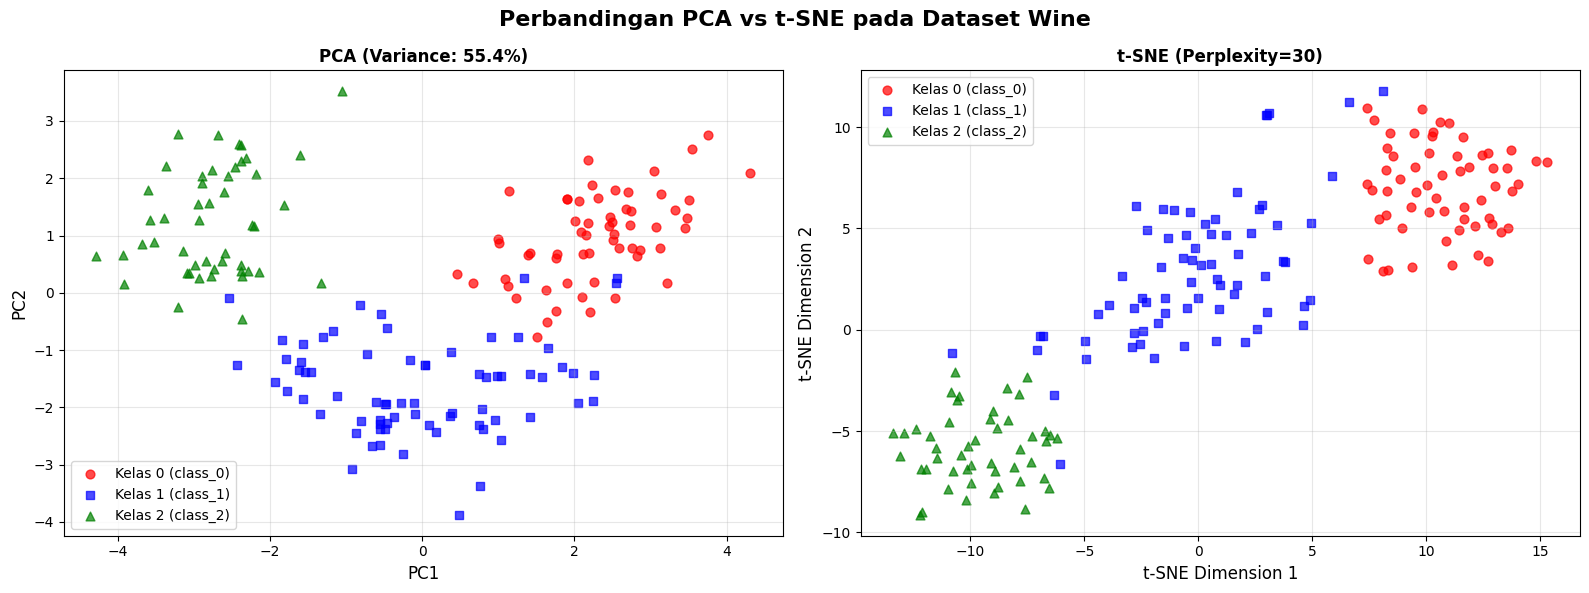

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, target_name in enumerate(target_names):
    axes[0].scatter(X_pca[y==i, 0], X_pca[y==i, 1],
                    c=colors[i], label=f'Kelas {i} ({target_name})',
                    alpha=0.7, s=40, marker=markers[i])
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title(f'PCA (Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)',
                  fontsize=12, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

for i, target_name in enumerate(target_names):
    axes[1].scatter(X_tsne[y==i, 0], X_tsne[y==i, 1],
                    c=colors[i], label=f'Kelas {i} ({target_name})',
                    alpha=0.7, s=40, marker=markers[i])
axes[1].set_xlabel('t-SNE Dimension 1', fontsize=12)
axes[1].set_ylabel('t-SNE Dimension 2', fontsize=12)
axes[1].set_title('t-SNE (Perplexity=30)', fontsize=12, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Perbandingan PCA vs t-SNE pada Dataset Wine',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/comparison.png', dpi=300, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


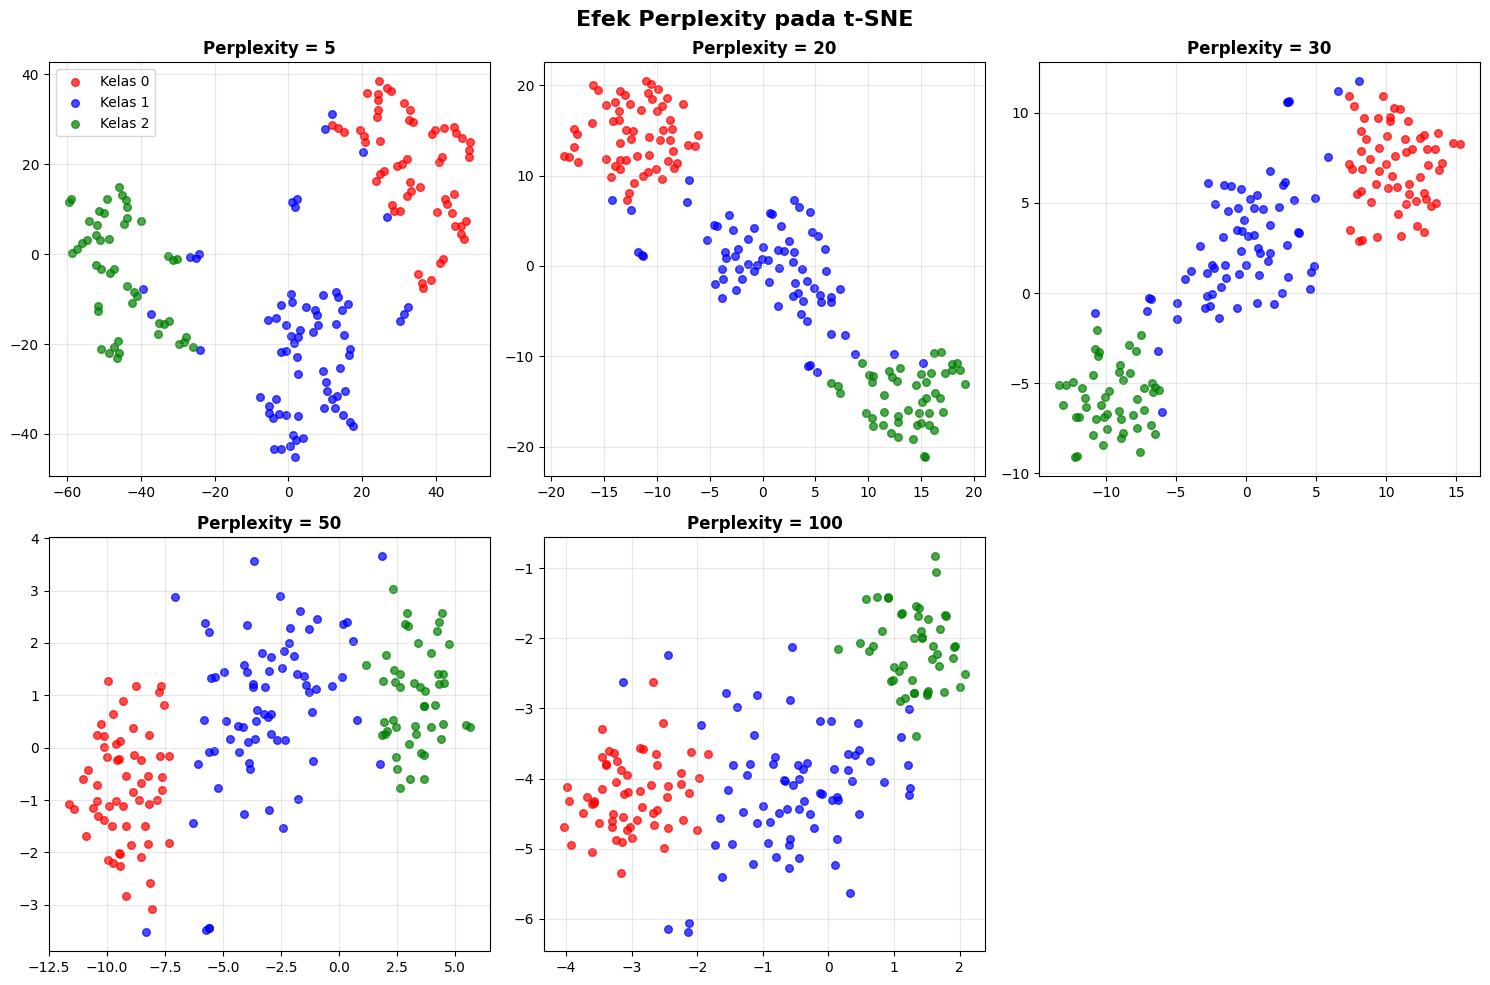

In [ ]:
perplexities = [5, 20, 30, 50, 100]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, perp in enumerate(perplexities):
    if idx < 5:
        tsne_exp = TSNE(n_components=2, random_state=42, perplexity=perp,
                       learning_rate=200, n_iter=1000)
        X_tsne_exp = tsne_exp.fit_transform(X_scaled)

        for i, target_name in enumerate(target_names):
            axes[idx].scatter(X_tsne_exp[y==i, 0], X_tsne_exp[y==i, 1],
                             c=colors[i], label=f'Kelas {i}',
                             alpha=0.7, s=30)
        axes[idx].set_title(f'Perplexity = {perp}', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        if idx == 0:
            axes[idx].legend(loc='best')

fig.delaxes(axes[5])

plt.suptitle('Efek Perplexity pada t-SNE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/perplexity_experiment.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print("\n" + "="*60)
print("RINGKASAN ANALISIS")
print("="*60)

print("\n📊 PCA (Principal Component Analysis):")
print(f"  - Total variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print("  - Kelebihan: Interpretable, cepat, linear")
print("  - Kekurangan: Kurang baik untuk data non-linear")

print("\n🎯 t-SNE (t-Distributed Stochastic Neighbor Embedding):")
print("  - Kelebihan: Mempertahankan struktur lokal, cluster jelas")
print("  - Kekurangan: Lambat, stochastic, sulit diinterpretasi")

print("\n💡 Kesimpulan:")
print("  - Untuk eksplorasi cluster: t-SNE lebih baik")
print("  - Untuk interpretasi fitur: PCA lebih baik")
print("  - Dataset Wine menunjukkan 3 cluster alami yang jelas")



RINGKASAN ANALISIS

📊 PCA (Principal Component Analysis):
  - Total variance explained: 55.41%
  - Kelebihan: Interpretable, cepat, linear
  - Kekurangan: Kurang baik untuk data non-linear

🎯 t-SNE (t-Distributed Stochastic Neighbor Embedding):
  - Kelebihan: Mempertahankan struktur lokal, cluster jelas
  - Kekurangan: Lambat, stochastic, sulit diinterpretasi

💡 Kesimpulan:
  - Untuk eksplorasi cluster: t-SNE lebih baik
  - Untuk interpretasi fitur: PCA lebih baik
  - Dataset Wine menunjukkan 3 cluster alami yang jelas
